In [1]:
import torch
import webdataset as wds
from pathlib import Path
import random
import folium
import branca.colormap as cm
import s2sphere
import matplotlib.pyplot as plt  
from transformers import AutoImageProcessor
from modules import *
from PIL import Image

In [2]:
def sample_random_batch(geo_dataset, batch_size=1, max_skip=1000):
    loader = wds.WebLoader(
        geo_dataset.dataset,
        batch_size=batch_size,
        num_workers=0,
    )
    it = iter(loader)
    for _ in range(random.randint(0, max_skip)):
        try:
            next(it)
        except StopIteration:
            it = iter(loader)
            break
    return next(it)  # (pixel_vals, class_vecs)


def probs_by_level(probs_fine, levels, parents, num_classes_per_level):
    fine_level = levels[-1]
    out = {fine_level: probs_fine}
    p = probs_fine.unsqueeze(0)  # (1, num_fine)
    for i, coarse in enumerate(levels[:-1]):
        parent = parents[(fine_level, coarse)]
        n = num_classes_per_level[i]
        pc = torch.zeros(1, n, device=probs_fine.device)
        pc.scatter_add_(1, parent.unsqueeze(0).expand(1, -1), p)
        out[coarse] = pc[0]
    return out


def s2_id_to_latlon(s2_id):
    ll = s2sphere.CellId(int(s2_id)).to_lat_lng()
    return float(ll.lat().degrees), float(ll.lng().degrees)


def s2_cell_corners(s2_id):
    cell = s2sphere.Cell(s2sphere.CellId(int(s2_id)))
    corners = []
    for i in range(4):
        v = cell.get_vertex(i)
        ll = s2sphere.LatLng.from_point(v)
        corners.append((float(ll.lat().degrees), float(ll.lng().degrees)))
    return corners


def make_prob_map(level, probs_per_level, idx2id):
    probs = probs_per_level[level].detach().cpu()
    ids = idx2id[level]

    m = folium.Map(location=[0, 0], zoom_start=2, tiles="cartodbpositron")
    cmap = cm.linear.YlOrRd_09.scale(float(probs.min()), float(probs.max()))

    lats, lons = [], []
    for idx, p in enumerate(probs):
        p = float(p)
        s2_id = ids[idx]
        corners = s2_cell_corners(s2_id)
        lats.extend([lat for lat, _ in corners])
        lons.extend([lon for _, lon in corners])

        color = cmap(p)
        folium.Polygon(
            locations=corners,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            popup=f"{s2_id} p={p:.3f}",
        ).add_to(m)

    if lats:
        m.fit_bounds([[min(lats), min(lons)], [max(lats), max(lons)]])
    cmap.add_to(m)
    return m


def show_image(img_tensor):
    """img_tensor: (C, H, W)"""
    img = img_tensor.detach().cpu()
    img = img.permute(1, 2, 0)  # HWC
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()

In [3]:
DATASET_PATH = Path("/home/austen/GeoDataset/dataset_sharded")
CHECKPOINT_PATH = Path("checkpoints/checkpoint_1235.pt") #checkpoint_384_2 #checkpoint_1235.pt
PRETRAINED_MODEL_ID = "facebook/convnext-base-384"
S2_LEVELS = list(range(3, 7))
RESIZE = 384
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

s2_labels_dir = DATASET_PATH / "s2_labels"
idx2id, id2idx, _ = build_s2_index_maps(s2_labels_dir, S2_LEVELS)

processor = AutoImageProcessor.from_pretrained(PRETRAINED_MODEL_ID, use_fast=True)
if RESIZE > 0:
    processor.do_resize = True
    processor.size = {"shortest_edge": RESIZE}
else:
    processor.do_resize = False
dataset = GeoWebDataset(
    DATASET_PATH,
    processor,
    levels=S2_LEVELS,
    shuffle=False,
    num_shards_limit=None,
    id2idx=id2idx,
)

parent_table = build_parent_tables_from_maps(idx2id, id2idx, S2_LEVELS)
PARENTS = {k: v.to(DEVICE) for k, v in parent_table.items()}
NUM_CLASSES_PER_LEVEL = dataset.num_classes_list

model = HierarchicalConvNeXt(
    pretrained_name=PRETRAINED_MODEL_ID,
    num_classes=NUM_CLASSES_PER_LEVEL[-1],
    freeze=False,
).to(DEVICE)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
_ = model.eval()

/tmp/ipykernel_960161/1697368241.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


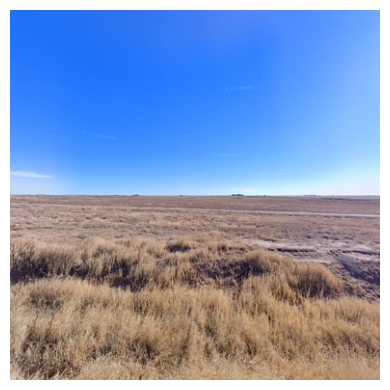

In [8]:
LEVEL_TO_SHOW = 4

pixel_vals, class_vecs = sample_random_batch(dataset)
img_tensor = pixel_vals[0]  

pixel_vals = pixel_vals.to(DEVICE, memory_format=torch.channels_last)

with torch.no_grad():
    logits = model(pixel_vals)
    probs_fine = torch.softmax(logits, dim=1)[0]

probs_per_level = probs_by_level(
    probs_fine,
    S2_LEVELS,
    PARENTS,
    NUM_CLASSES_PER_LEVEL,
)

show_image(img_tensor)

m = make_prob_map(
    level=LEVEL_TO_SHOW,
    probs_per_level=probs_per_level,
    idx2id=idx2id,
)

level_idx = S2_LEVELS.index(LEVEL_TO_SHOW)
correct_class_idx = int(class_vecs[0, level_idx])
correct_s2_id = idx2id[LEVEL_TO_SHOW][correct_class_idx]
clat, clon = s2_id_to_latlon(correct_s2_id)

folium.Marker(
    [clat, clon],
    popup=f"CORRECT (level {LEVEL_TO_SHOW}): {correct_s2_id}",
).add_to(m)

m

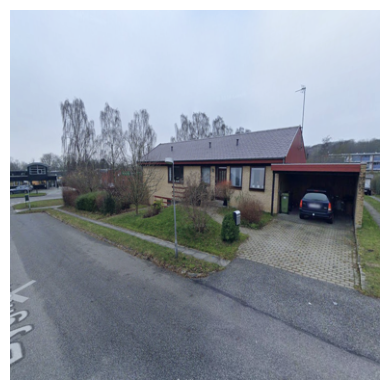

In [7]:
LOCAL_IMAGE_PATH = "test_images/12345678.PNG"
LAT, LON = 56.234479, 10.237352

img = Image.open(LOCAL_IMAGE_PATH).convert("RGB")
inputs = processor(images=img, return_tensors="pt")  
pixel_vals = inputs["pixel_values"] 
img_tensor = pixel_vals[0]                

pixel_vals = pixel_vals.to(DEVICE, memory_format=torch.channels_last)

with torch.no_grad():
    logits = model(pixel_vals)
    probs_fine = torch.softmax(logits, dim=1)[0]

probs_per_level = probs_by_level(
    probs_fine,
    S2_LEVELS,
    PARENTS,
    NUM_CLASSES_PER_LEVEL,
)

show_image(img_tensor)

LEVEL_TO_SHOW = 6

m = make_prob_map(
    level=LEVEL_TO_SHOW,
    probs_per_level=probs_per_level,
    idx2id=idx2id,
)

folium.Marker(
    [LAT, LON],
    popup=f"CORRECT (level {LEVEL_TO_SHOW}): {correct_s2_id}",
).add_to(m)

m
